In [1]:
import tensorflow as tf
from tensorflow import keras

In [2]:
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [3]:
import tensorflow_datasets as tfds

# Try to resolve Protobuf version incompatibility by reinstalling tensorflow-datasets and protobuf
# This often happens due to conflicting dependency versions between packages.
!pip uninstall -y tensorflow-datasets protobuf
!pip install tensorflow-datasets protobuf --upgrade

# It is highly recommended to restart the Colab runtime after this step
# (Runtime -> Restart runtime) for the changes to take full effect.

dataset = tfds.load("oxford_iiit_pet")

Found existing installation: tensorflow-datasets 4.9.10
Uninstalling tensorflow-datasets-4.9.10:
  Successfully uninstalled tensorflow-datasets-4.9.10
Found existing installation: protobuf 7.35.1
Uninstalling protobuf-7.35.1:
  Successfully uninstalled protobuf-7.35.1
  Using cached tensorflow_datasets-4.9.10-py3-none-any.whl.metadata (11 kB)
  Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
Using cached tensorflow_datasets-4.9.10-py3-none-any.whl (5.3 MB)
Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl (327 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have prot

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.YWS5B4_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.YWS5B4_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [58]:
train_dataset = dataset['train']

In [59]:
validation_dataset = dataset['test']

In [63]:
IMG_SIZE = 224
NUM_CLASSES = 1

def preprocess_data(element):
    image = element['image']
    original_label = element['label']

    # Resize image
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # Normalize image to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0

    # Convert original_label to 0-indexed breed label
    # The dataset labels are 0-indexed (0-36), so no subtraction needed
    breed_label = tf.cast(original_label, tf.int32)
    # Clip breed_label to ensure it's within [0, 36] to handle any unexpected negative values
    breed_label = tf.clip_by_value(breed_label, 0, 36)

    # Derive species label: 0 for cat (labels 0-11), 1 for dog (labels 12-36)
    # Since original_label is 0-indexed, cats are original_label <= 11
    specie_label = tf.cast(original_label >= 12, tf.float32) # 0.0 for cat, 1.0 for dog

    return image, {'specie_output': specie_label, 'breed_output': breed_label}

In [65]:
BATCH_SIZE = 32 # Define batch size here

# Apply the preprocessing function to the datasets, then shuffle, batch, and prefetch
# Temporarily removing .cache() to debug potential caching issues with labels
batched_train_dataset = train_dataset.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)
batched_train_dataset = batched_train_dataset.shuffle(500).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

batched_validation_dataset = validation_dataset.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)
batched_validation_dataset = batched_validation_dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

print("Datasets preprocessed, shuffled, batched, and prefetched successfully with two outputs (cache removed for debugging).")

Datasets preprocessed, shuffled, batched, and prefetched successfully with two outputs (cache removed for debugging).


In [7]:
data_augmentation=keras.Sequential([
    layers.RandomFlip('Horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1,0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1)
])

In [29]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

In [30]:
base_model.trainable=False

In [42]:
input=keras.Input(shape=(224,224,3))
x = base_model(input)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128,activation='leaky_relu')(x)
x = layers.Dense(64,activation='leaky_relu')(x)
x = layers.Dense(32,activation='leaky_relu')(x)
x = layers.Dense(16,activation='leaky_relu')(x)
drop = Dropout(0.2)(x)
specie_output = layers.Dense(1,activation='sigmoid', name='specie_output')(drop)
breed_output = layers.Dense(37,activation='softmax', name='breed_output')(drop) # Assuming 37 breeds in the dataset
model = keras.Model(inputs=input, outputs=[specie_output, breed_output])

In [43]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_6[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[1… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      8,256 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │      2,080 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 16)        │        528 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ specie_output       │ (None, 1)         │         17 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ breed_output        │ (None, 37)        │        629 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,225,049 (16.12 MB)

 Trainable params: 175,478 (685.46 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

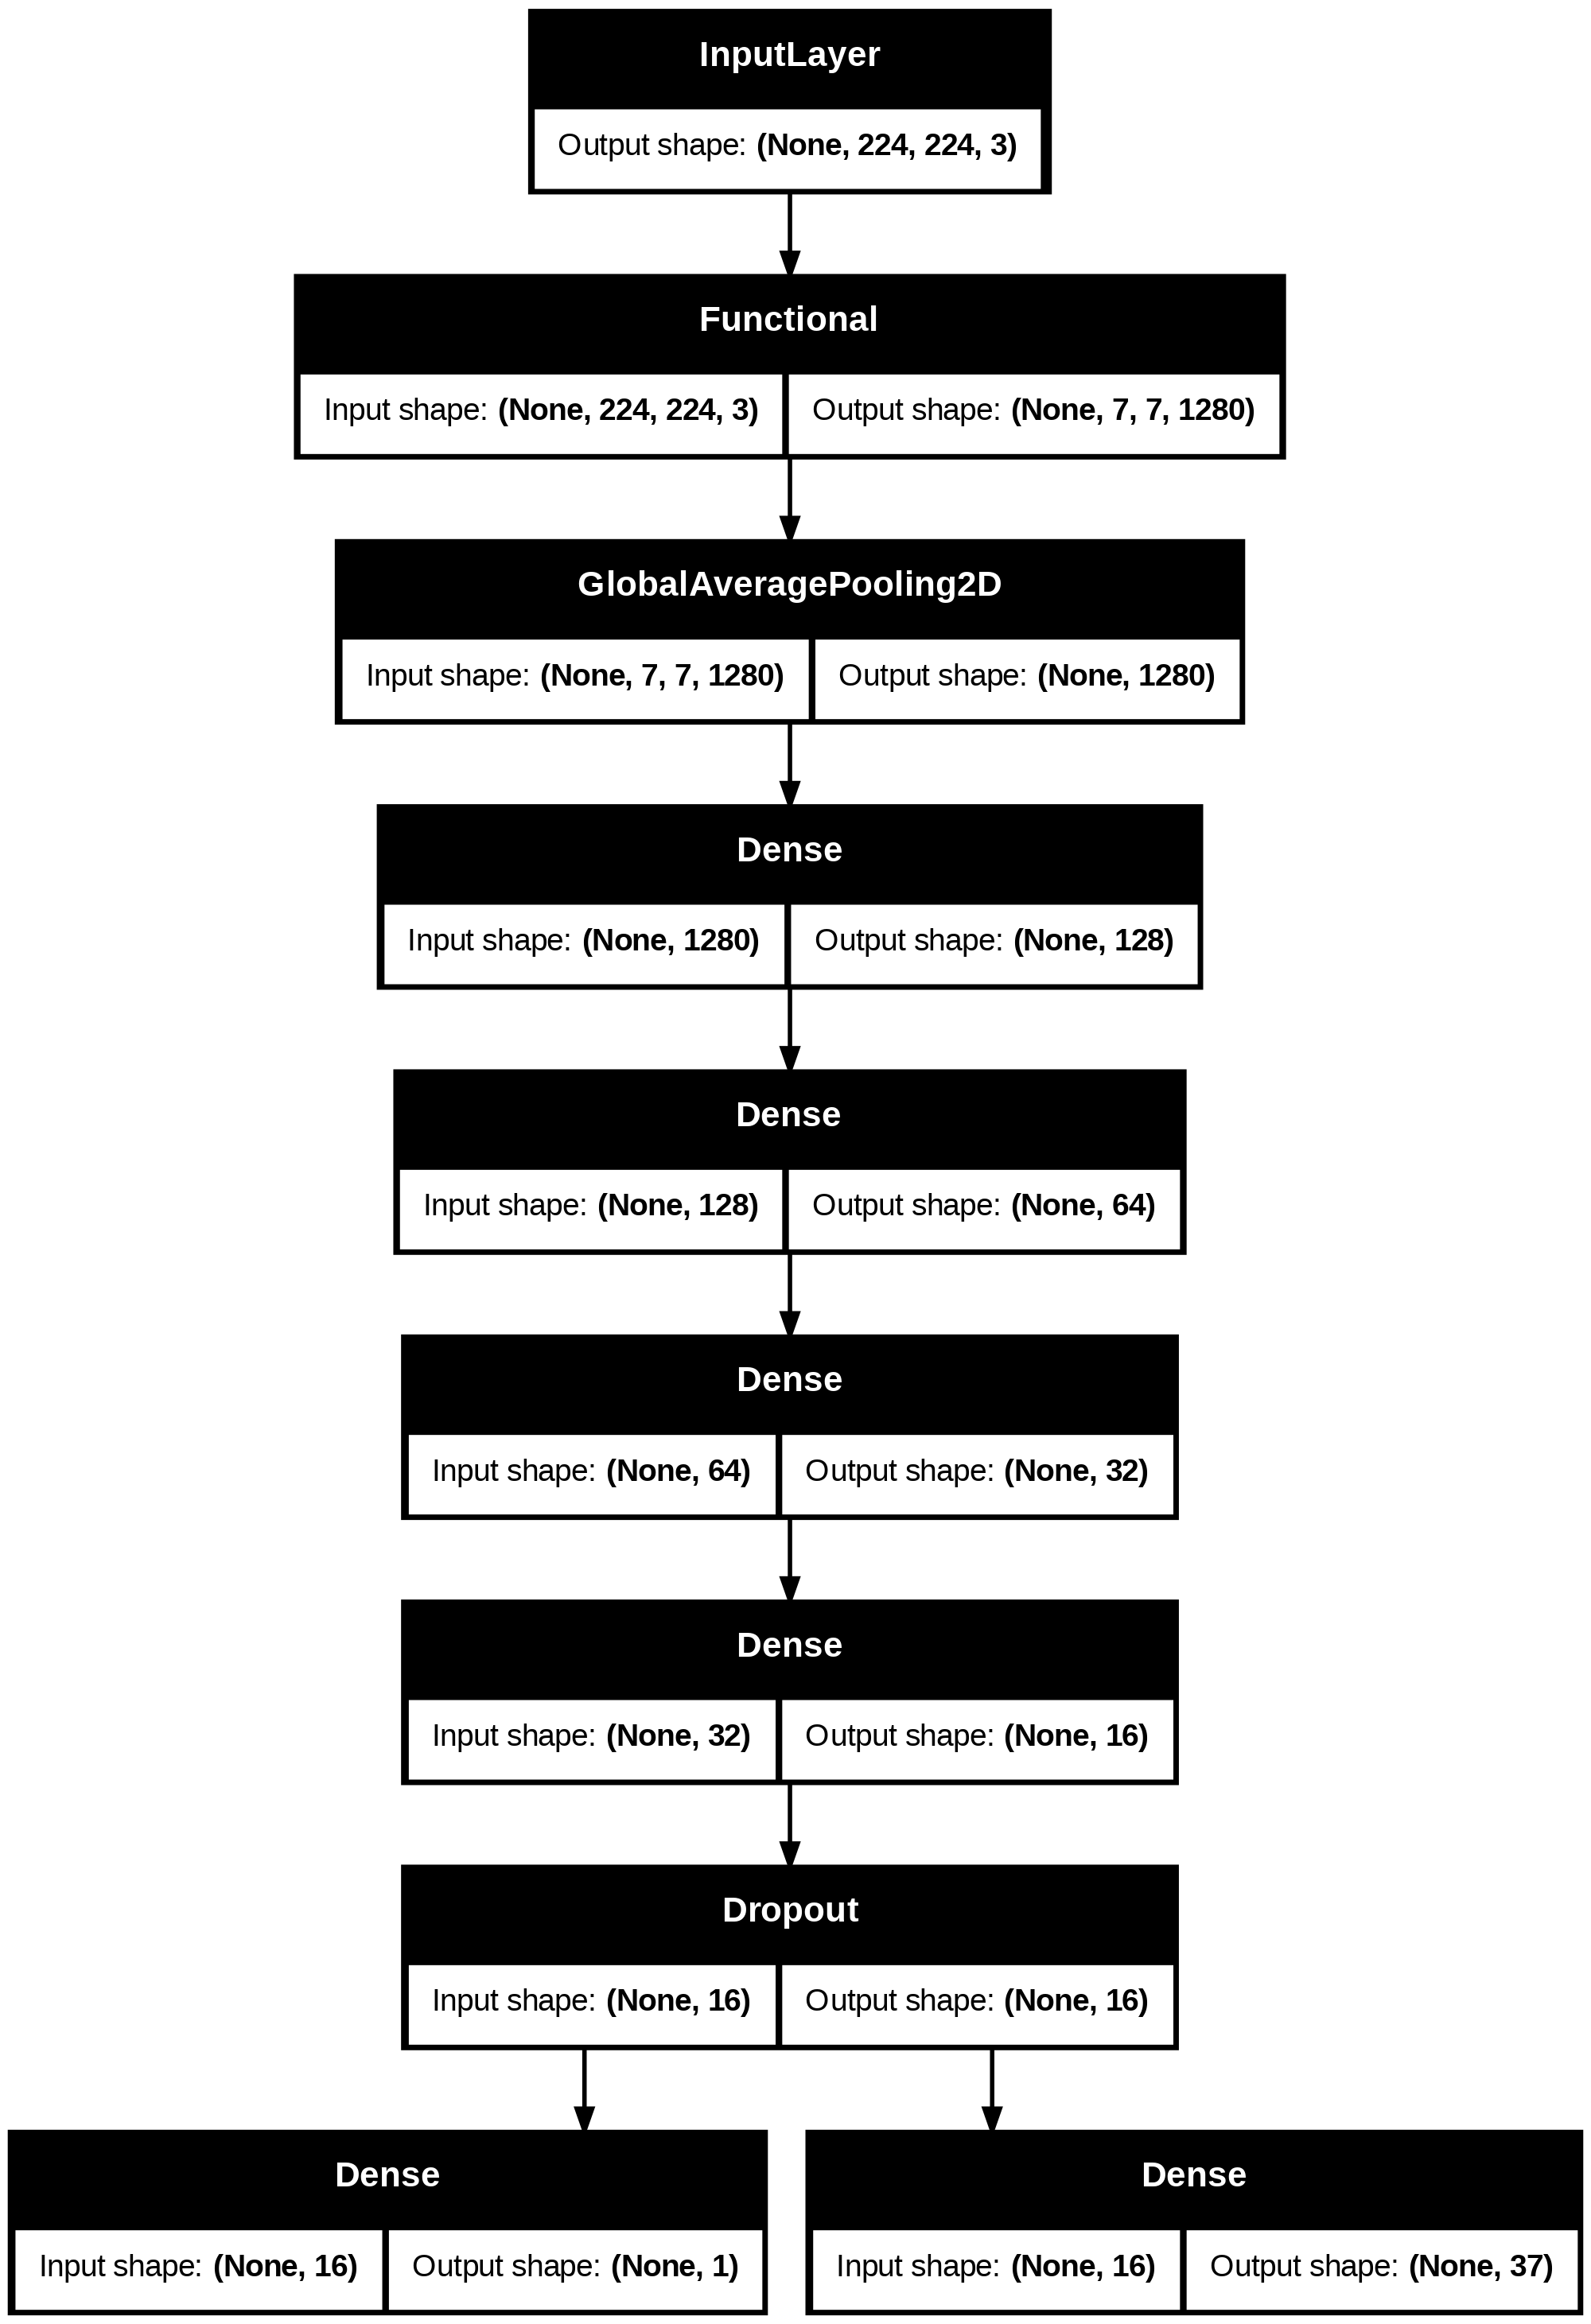

In [44]:
from tensorflow.keras.utils import plot_model
plot_model(model,show_shapes=True)

In [47]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.00001),
    loss={
        'specie_output': 'binary_crossentropy',
        'breed_output': 'sparse_categorical_crossentropy' # Use sparse_categorical_crossentropy for integer labels
    },
    metrics={
        'specie_output': ['accuracy'],
        'breed_output': ['accuracy']
    }
)

In [46]:
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint

In [67]:
call_back=[
    EarlyStopping(monitor='val_loss',patience=3,verbose=1,restore_best_weights=True),
    ModelCheckpoint('model.h5',monitor='val_loss',save_best_only=True,verbose=1)
]

In [68]:
history=model.fit(batched_train_dataset,epochs=8,validation_data=batched_validation_dataset,callbacks=[call_back])

Epoch 1/8
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - breed_output_accuracy: 0.0299 - breed_output_loss: 3.6207 - loss: 4.2804 - specie_output_accuracy: 0.6623 - specie_output_loss: 0.6598
Epoch 1: val_loss improved from None to 4.25319, saving model to model.h5



Epoch 1: finished saving model to model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 466s 4s/step - breed_output_accuracy: 0.0307 - breed_output_loss: 3.6180 - loss: 4.2652 - specie_output_accuracy: 0.6764 - specie_output_loss: 0.6472 - val_breed_output_accuracy: 0.0273 - val_breed_output_loss: 3.6196 - val_loss: 4.2532 - val_specie_output_accuracy: 0.6778 - val_specie_output_loss: 0.6338
Epoch 2/8
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - breed_output_accuracy: 0.0261 - breed_output_loss: 3.6215 - loss: 4.2675 - specie_output_accuracy: 0.6613 - specie_output_loss: 0.6460
Epoch 2: val_loss improved from 4.25319 to 4.24958, saving model to model.h5



Epoch 2: finished saving model to model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 487s 4s/step - breed_output_accuracy: 0.0231 - breed_output_loss: 3.6193 - loss: 4.2566 - specie_output_accuracy: 0.6769 - specie_output_loss: 0.6373 - val_breed_output_accuracy: 0.0273 - val_breed_output_loss: 3.6182 - val_loss: 4.2496 - val_specie_output_accuracy: 0.6778 - val_specie_output_loss: 0.6315
Epoch 3/8
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - breed_output_accuracy: 0.0230 - breed_output_loss: 3.6223 - loss: 4.2627 - specie_output_accuracy: 0.6647 - specie_output_loss: 0.6405
Epoch 3: val_loss improved from 4.24958 to 4.24830, saving model to model.h5



Epoch 3: finished saving model to model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 484s 4s/step - breed_output_accuracy: 0.0245 - breed_output_loss: 3.6200 - loss: 4.2537 - specie_output_accuracy: 0.6769 - specie_output_loss: 0.6337 - val_breed_output_accuracy: 0.0273 - val_breed_output_loss: 3.6177 - val_loss: 4.2483 - val_specie_output_accuracy: 0.6778 - val_specie_output_loss: 0.6307
Epoch 4/8
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - breed_output_accuracy: 0.0301 - breed_output_loss: 3.6163 - loss: 4.2611 - specie_output_accuracy: 0.6578 - specie_output_loss: 0.6447
Epoch 4: val_loss improved from 4.24830 to 4.24774, saving model to model.h5



Epoch 4: finished saving model to model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 491s 4s/step - breed_output_accuracy: 0.0283 - breed_output_loss: 3.6178 - loss: 4.2516 - specie_output_accuracy: 0.6769 - specie_output_loss: 0.6337 - val_breed_output_accuracy: 0.0273 - val_breed_output_loss: 3.6178 - val_loss: 4.2477 - val_specie_output_accuracy: 0.6778 - val_specie_output_loss: 0.6301
Epoch 5/8
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - breed_output_accuracy: 0.0257 - breed_output_loss: 3.6190 - loss: 4.2614 - specie_output_accuracy: 0.6597 - specie_output_loss: 0.6425
Epoch 5: val_loss improved from 4.24774 to 4.24756, saving model to model.h5



Epoch 5: finished saving model to model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 480s 4s/step - breed_output_accuracy: 0.0280 - breed_output_loss: 3.6183 - loss: 4.2512 - specie_output_accuracy: 0.6769 - specie_output_loss: 0.6328 - val_breed_output_accuracy: 0.0270 - val_breed_output_loss: 3.6182 - val_loss: 4.2476 - val_specie_output_accuracy: 0.6778 - val_specie_output_loss: 0.6295
Epoch 6/8
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - breed_output_accuracy: 0.0224 - breed_output_loss: 3.6185 - loss: 4.2619 - specie_output_accuracy: 0.6620 - specie_output_loss: 0.6434
Epoch 6: val_loss improved from 4.24756 to 4.24724, saving model to model.h5



Epoch 6: finished saving model to model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 427s 4s/step - breed_output_accuracy: 0.0247 - breed_output_loss: 3.6176 - loss: 4.2521 - specie_output_accuracy: 0.6769 - specie_output_loss: 0.6345 - val_breed_output_accuracy: 0.0270 - val_breed_output_loss: 3.6177 - val_loss: 4.2472 - val_specie_output_accuracy: 0.6778 - val_specie_output_loss: 0.6297
Epoch 7/8
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - breed_output_accuracy: 0.0249 - breed_output_loss: 3.6218 - loss: 4.2628 - specie_output_accuracy: 0.6634 - specie_output_loss: 0.6409
Epoch 7: val_loss did not improve from 4.24724
115/115 ━━━━━━━━━━━━━━━━━━━━ 447s 4s/step - breed_output_accuracy: 0.0272 - breed_output_loss: 3.6190 - loss: 4.2526 - specie_output_accuracy: 0.6769 - specie_output_loss: 0.6336 - val_breed_output_accuracy: 0.0270 - val_breed_output_loss: 3.6181 - val_loss: 4.2474 - val_specie_output_accuracy: 0.6778 - val_specie_output_loss: 0.6294
Epoch 8/8
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step 


Epoch 8: finished saving model to model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 441s 4s/step - breed_output_accuracy: 0.0250 - breed_output_loss: 3.6193 - loss: 4.2540 - specie_output_accuracy: 0.6769 - specie_output_loss: 0.6347 - val_breed_output_accuracy: 0.0270 - val_breed_output_loss: 3.6175 - val_loss: 4.2470 - val_specie_output_accuracy: 0.6778 - val_specie_output_loss: 0.6296
Restoring model weights from the end of the best epoch: 8.


In [73]:
results = model.evaluate(batched_validation_dataset)
print(f"Total Loss: {round(results[0], 4)}")
print(f"Specie Output Loss: {round(results[1], 4)}")
print(f"Specie Output Accuracy: {round(results[2], 4)}")
print(f"Breed Output Loss: {round(results[3], 4)}")
print(f"Breed Output Accuracy: {round(results[4], 4)}")

115/115 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - breed_output_accuracy: 0.0270 - breed_output_loss: 3.6175 - loss: 4.2470 - specie_output_accuracy: 0.6778 - specie_output_loss: 0.6296
Total Loss: 4.247
Specie Output Loss: 0.6296
Specie Output Accuracy: 3.6175
Breed Output Loss: 0.027
Breed Output Accuracy: 0.6778


In [70]:
import matplotlib.pyplot as plt

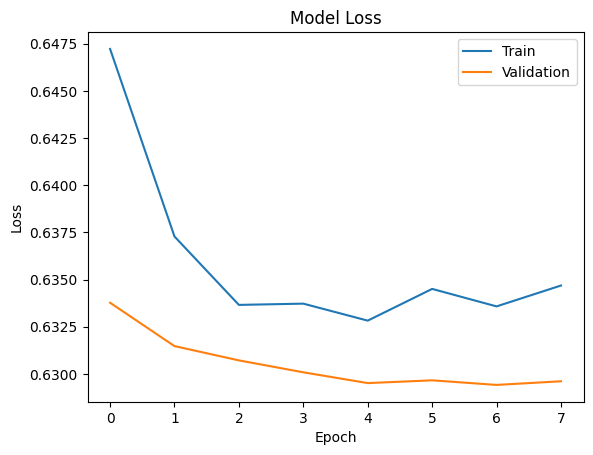

In [74]:
plt.plot(history.history['specie_output_loss'])
plt.plot(history.history['val_specie_output_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

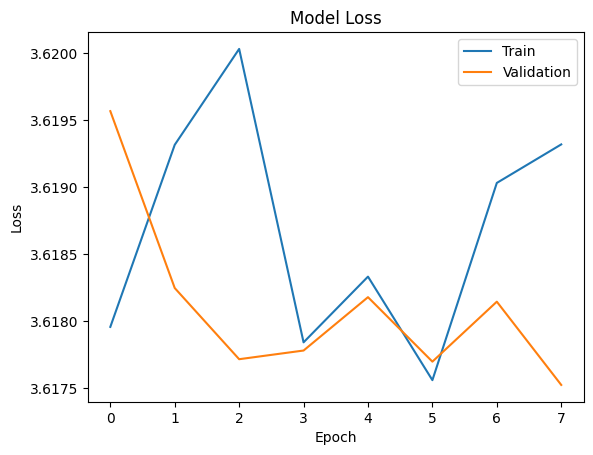

In [75]:
plt.plot(history.history['breed_output_loss'])
plt.plot(history.history['val_breed_output_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

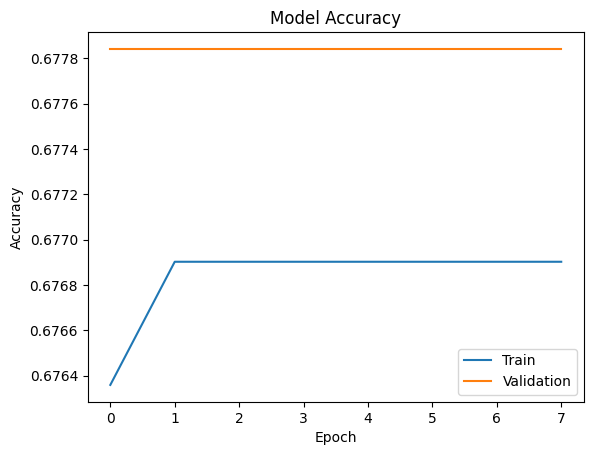

In [76]:
plt.plot(history.history['specie_output_accuracy'])
plt.plot(history.history['val_specie_output_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

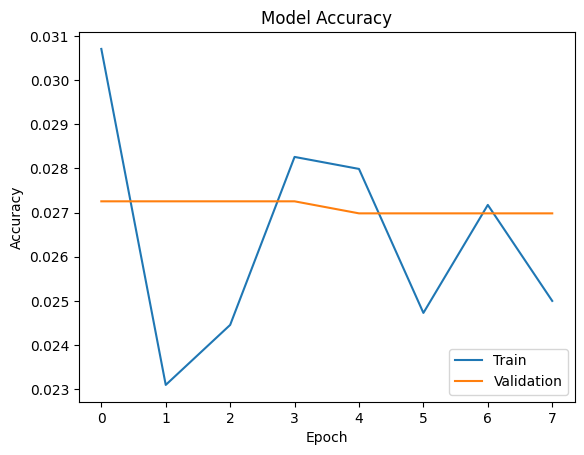

In [77]:
plt.plot(history.history['breed_output_accuracy'])
plt.plot(history.history['val_breed_output_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()